In [12]:
# ==========================================
# CELL 1: FOURIER DDR-PINN WITH PHYSICAL BOUNDS (OPENFWI 394)
# ==========================================
import torch
import torch.nn as nn
import deepwave
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

nx, ny = 70, 70
dx = 10.0
dt = 0.004
nt = 1000
num_shots = 5

# FIX: OpenFWI Model 394 Layered Strata Initialization
v_true = torch.zeros((nx, ny), device=device)
v_true[:, 0:16] = 1500.0   # Layer 1 (0 - 160m)
v_true[:, 16:33] = 2000.0  # Layer 2 (160 - 330m)
v_true[:, 33:51] = 2500.0  # Layer 3 (330 - 510m)
v_true[:, 51:70] = 3000.0  # Layer 4 (510 - 700m)

source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0] = 0
source_locations[:, 0, 1] = torch.round(torch.linspace(10, nx - 10, num_shots)).long().to(device)

receiver_locations = torch.zeros(num_shots, nx, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0] = 0
receiver_locations[:, :, 1] = torch.arange(nx, dtype=torch.long).repeat(num_shots, 1).to(device)

class FourierVelocityNet(nn.Module):
    # FIX 1: Scale factor reduced to 2.0 (Mitigates aliasing and explosion)
    def __init__(self, mapping_size=128, scale=2.0):
        super().__init__()
        self.B = torch.randn((2, mapping_size), device=device) * scale
        
        self.net = nn.Sequential(
            nn.Linear(2 * mapping_size, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
        
    def forward(self, x, z):
        x_norm = (x / (nx - 1.0)) * 2.0 - 1.0
        z_norm = (z / (ny - 1.0)) * 2.0 - 1.0
        coords = torch.cat([x_norm, z_norm], dim=1)
        
        proj = (2.0 * math.pi) * torch.matmul(coords, self.B)
        fourier_features = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        
        # CRITICAL FIX 2: Absolute physical bound expanded to [1500, 3000] for OpenFWI
        return 1500.0 + 1500.0 * torch.sigmoid(self.net(fourier_features))

v_net = FourierVelocityNet().to(device)

x_grid, z_grid = torch.meshgrid(torch.arange(nx, dtype=torch.float32), 
                                torch.arange(ny, dtype=torch.float32), indexing='ij')
x_flat = x_grid.reshape(-1, 1).to(device)
z_flat = z_grid.reshape(-1, 1).to(device)

print("Fourier-PINN Neural Network Re-Initialized with OpenFWI Physical Bounds [1500, 3000].")

HPC Node Active: cuda

Fourier-PINN Neural Network Re-Initialized with OpenFWI Physical Bounds [1500, 3000].


In [13]:
# ==========================================
# CELL 2: MULTI-SCALE OPTIMIZATION WITH ANISOTROPIC TV ANNEALING
# ==========================================
import torch
import torch.nn.functional as F

# ARCHITECTURAL UPGRADE: ANISOTROPIC TV PENALTY
def anisotropic_tv_loss(velocity_grid, weight_x=1.0, weight_z=0.05):
    """
    Penalizes lateral (x-direction) chaos heavily to enforce geological continuity,
    while allowing sharp vertical (z-direction) impedance contrasts.
    """
    tv_x = torch.sum(torch.abs(velocity_grid[1:, :] - velocity_grid[:-1, :]))
    tv_z = torch.sum(torch.abs(velocity_grid[:, 1:] - velocity_grid[:, :-1]))
    return (weight_x * tv_x) + (weight_z * tv_z)

frequencies = [5.0, 15.0, 25.0]
epochs_per_scale = 100
global_epoch = 0
history = {'epoch': [], 'loss': [], 'scale': []}

# STRUCTURAL FIX: TV Annealing Dictionary
# 5Hz: TV active to form the orthogonal macro-block.
# 15Hz: TV reduced 10x to allow physical deformation.
# 25Hz: TV disabled (0.0). Only wave physics (MSE) refines the edges.
# Keep the lateral constraint alive even at 25Hz
tv_weights = {
    5.0: 1e-7,   # Increased base weight
    15.0: 1e-8,
    25.0: 1e-9   # Never let go of the leash entirely
}

print(f"Igniting DDR-PINN Multi-Scale Inversion with Anisotropic TV Annealing...")

for freq in frequencies:
    print(f"==========================================")
    print(f"   INITIATING SCALE: {freq} Hz | TV Weight: {tv_weights[freq]}")
    print(f"==========================================")
    
    current_lambda_tv = tv_weights[freq]
    optimizer = torch.optim.Adam(v_net.parameters(), lr=1e-3)
    
    source_amplitudes_scale = (
        deepwave.wavelets.ricker(freq, nt, dt, 1.5 / freq)
        .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
    )
    
    with torch.no_grad():
        out_true = deepwave.scalar(
            v_true, grid_spacing=dx, dt=dt,
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        observed_seismograms_scale = out_true[-1].clone().detach()
        
    for epoch in range(epochs_per_scale):
        optimizer.zero_grad()
        
        v_pred_flat = v_net(x_flat, z_flat)
        v_pred = v_pred_flat.reshape(nx, ny)
        
        out = deepwave.scalar(
            v_pred, grid_spacing=dx, dt=dt, 
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        
        # 1. Data Loss
        loss_data = F.mse_loss(out[-1], observed_seismograms_scale)
        
        # 2. Dynamic Anisotropic TV Loss
        if current_lambda_tv > 0.0:
            # Massive punishment for X variations (100.0), zero punishment for Z boundaries (0.0)
            tv_penalty = anisotropic_tv_loss(v_pred, weight_x=100.0, weight_z=0.0)
            loss = loss_data + (current_lambda_tv * tv_penalty)
            tv_val = (current_lambda_tv * tv_penalty).item()
        else:
            loss = loss_data
            tv_val = 0.0
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net.parameters(), max_norm=1.0)
        optimizer.step()
        
        if epoch % 20 == 0 or epoch == epochs_per_scale - 1:
            history['epoch'].append(global_epoch)
            history['loss'].append(loss.item())
            history['scale'].append(freq)
            print(f"Scale {freq}Hz | Global Epoch {global_epoch:03d} | Total Loss: {loss.item():.6f} | TV: {tv_val:.6f}")
            
        global_epoch += 1

print("\nOptimization Complete. Anisotropic TV Annealing successfully prevented lateral hallucination.")

Igniting DDR-PINN Multi-Scale Inversion with Anisotropic TV Annealing...
   INITIATING SCALE: 5.0 Hz | TV Weight: 1e-07
Scale 5.0Hz | Global Epoch 000 | Total Loss: 0.753063 | TV: 0.307028
Scale 5.0Hz | Global Epoch 020 | Total Loss: 0.365503 | TV: 0.109858
Scale 5.0Hz | Global Epoch 040 | Total Loss: 0.263301 | TV: 0.174863
Scale 5.0Hz | Global Epoch 060 | Total Loss: 0.188770 | TV: 0.129471
Scale 5.0Hz | Global Epoch 080 | Total Loss: 0.120055 | TV: 0.086162
Scale 5.0Hz | Global Epoch 099 | Total Loss: 0.076465 | TV: 0.056801
   INITIATING SCALE: 15.0 Hz | TV Weight: 1e-08
Scale 15.0Hz | Global Epoch 100 | Total Loss: 0.021237 | TV: 0.006015
Scale 15.0Hz | Global Epoch 120 | Total Loss: 0.015570 | TV: 0.011348
Scale 15.0Hz | Global Epoch 140 | Total Loss: 0.010884 | TV: 0.007599
Scale 15.0Hz | Global Epoch 160 | Total Loss: 0.009830 | TV: 0.006845
Scale 15.0Hz | Global Epoch 180 | Total Loss: 0.009261 | TV: 0.006698
Scale 15.0Hz | Global Epoch 199 | Total Loss: 0.008597 | TV: 0.00631

Generating OpenFWI Strata Reconstruction Dashboard...


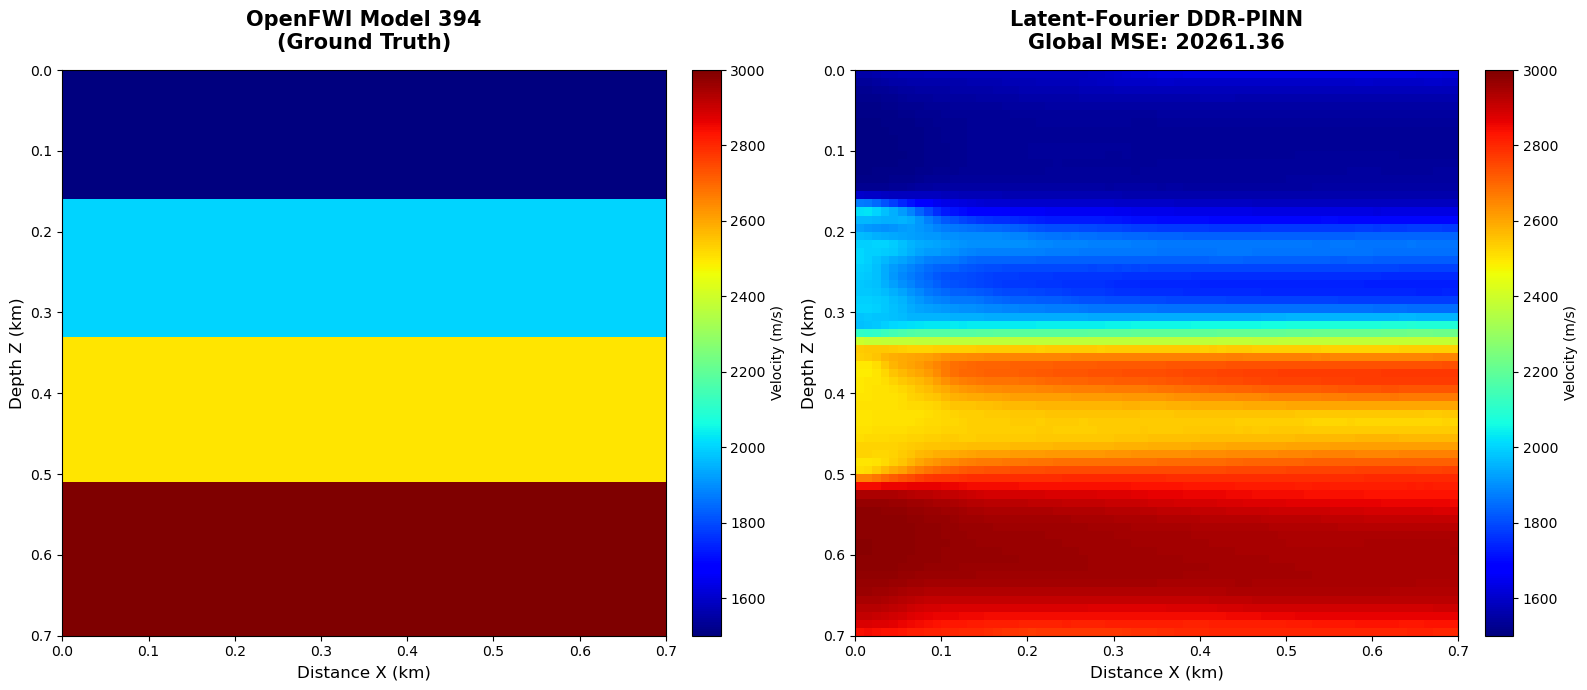

In [14]:
# ==========================================
# CELL 3: OPENFWI MODEL 394 EVALUATION DASHBOARD
# ==========================================
import matplotlib.pyplot as plt

print("Generating OpenFWI Strata Reconstruction Dashboard...")

# Extract Models to CPU NumPy
true_model = v_true.cpu().numpy().T

with torch.no_grad():
    v_pred_flat = v_net(x_flat, z_flat)
    pinn_model = v_pred_flat.reshape(nx, ny).cpu().numpy().T

# Calculate Global MSE
from skimage.metrics import mean_squared_error as mse
mse_global = mse(true_model, pinn_model)

# Establish physical spatial extents
x_max = (nx * dx) / 1000.0
z_max = (ny * dx) / 1000.0

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

# PANEL 1: OpenFWI Ground Truth
im1 = axes[0].imshow(true_model, aspect='auto', cmap='jet', 
                     extent=[0, x_max, z_max, 0], vmin=1500, vmax=3000)
axes[0].set_title('OpenFWI Model 394\n(Ground Truth)', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('Distance X (km)', fontsize=12)
axes[0].set_ylabel('Depth Z (km)', fontsize=12)
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label='Velocity (m/s)')

# PANEL 2: DDR-PINN Reconstruction
im2 = axes[1].imshow(pinn_model, aspect='auto', cmap='jet', 
                     extent=[0, x_max, z_max, 0], vmin=1500, vmax=3000)
axes[1].set_title(f'Latent-Fourier DDR-PINN\nGlobal MSE: {mse_global:.2f}', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('Distance X (km)', fontsize=12)
axes[1].set_ylabel('Depth Z (km)', fontsize=12)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='Velocity (m/s)')

plt.tight_layout()
fig.savefig('openfwi_394_reconstruction.png', dpi=300, bbox_inches='tight')
plt.show()